# UMAP Analysis

In this notebook, we try and see whether or not time/temporal concepts exist on some sort of
1. Easily separable manifold. We will train on ambivalent temporal phrases, where the timescale can be short and term (e.g. "I will go to the gym now/later")
2. Parameterizable manifold when considering a log time progression of goals. We will train on statements involving specific time ranges.


Let us discern whether
1. SAE is useful for this (this should be easy for UMAP to train, but will depend on quality of SAE)
2. Residual stream is enough (much harder with entanglement)

I'm assuming that UMAP is more sophisticated and the correct analysis tool compared to t-SNE.

## Imports and basic setup

Feel free to ignore

In [12]:
import torch
import numpy as np
import json
import re
import random
import argparse
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tqdm import tqdm
from datetime import datetime
from dataclasses import dataclass, field, asdict
from typing import Dict, List, Tuple, Optional, Any
from abc import ABC, abstractmethod

from transformer_lens import HookedTransformer
from sae_lens import SAE


In [13]:
device = "cpu"

@dataclass
class ExperimentConfig:
    """Configuration for steering vector comparison experiment."""
    # Model settings
    model_name: str = "gemma-2-2b"
    sae_release: str = "gemma-scope-2b-pt-res-canonical"
    device: str = "cpu"

    # Layer settings
    layers: List[int] = field(default_factory=lambda: [6, 13, 20, 24])

    # SAE settings
    top_k_latents: int = 64
    sae_width: str = "16k"

    def to_dict(self) -> dict:
        return asdict(self)


In [14]:
config = ExperimentConfig()

## Part 1

Dataset with now/later. We will use the temporal_scope_implicit.json and temporal_scope_clean.json

This is a pretty hard dataset, there's a lot of implicit data in there.

In [15]:
DATA_DIR = Path("../data/raw")

def load_temporal_dataset():
    """Load temporal scope datasets and return texts with binary labels.

    Reads temporal_scope_clean.json and temporal_scope_implicit_expanded.json,
    creating one sample per (question + answer) combination.

    Returns:
        texts: list[str]  — each entry is question + answer text
        labels: list[int] — 0 for immediate, 1 for long_term
        sources: list[str] — which file each sample came from
    """
    files = [
        "temporal_scope_clean.json",
        "temporal_scope_implicit_expanded.json",
        "temporal_scope_pairs_minimal.json",
    ]

    texts = []
    labels = []
    sources = []

    for fname in files:
        with open(DATA_DIR / fname) as f:
            data = json.load(f)

        for pair in data["pairs"]:
            if "question" in pair:
                question = pair["question"]

                # immediate → label 0
                texts.append(question.strip(":") + pair["immediate"][4:].lower() + '.')
                labels.append(0)
                sources.append(fname)

                # long_term → label 1
                texts.append(question.strip(":") + pair["long_term"][4:].lower() + '.')
                labels.append(1)
                sources.append(fname)
            else:
                # immediate → label 0
                texts.append(pair["immediate"].lower() + '.')
                labels.append(0)
                sources.append(fname)

                # long_term → label 1
                texts.append(pair["long_term"].lower() + '.')
                labels.append(1)
                sources.append(fname)


    print(f"Loaded {len(texts)} samples ({labels.count(0)} immediate, {labels.count(1)} long_term)")
    return texts, labels, sources

In [16]:
texts, labels, sources = load_temporal_dataset()


Loaded 600 samples (300 immediate, 300 long_term)


In [17]:
sample_indices = random.sample(range(len(texts)), 5)
for i in sample_indices:
    label_name = "immediate" if labels[i] == 0 else "long_term"
    print(f"[{label_name}] {texts[i]}\n")

[immediate] Attention goes to protecting and safeguarding.

[immediate] The right trade-off favors certainty over potential.

[immediate] Learning should target skills needed this week.

[immediate] The best use of time is maximizing today's productivity.

[long_term] architecture.



## Load model and get activations

In [18]:
model = HookedTransformer.from_pretrained(config.model_name, device=config.device)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded pretrained model gemma-2-2b into HookedTransformer


In [19]:
def extract_activations(model: HookedTransformer, prompts: List[str], layer: int,
                        sae: Optional[SAE] = None, batch_size: int = 16,
                        ) -> Tuple[np.ndarray, Optional[np.ndarray]]:
    hook_name = f"blocks.{layer}.hook_resid_post"
    all_raw_acts = []
    all_sae_latents = [] if sae else None

    for i in tqdm(range(0, len(prompts), batch_size), desc="Batches"):
        batch_prompts = prompts[i:i + batch_size]

        with torch.no_grad():
            _, cache = model.run_with_cache(
                batch_prompts,
                names_filter=[hook_name],
                stop_at_layer=layer + 1,
            )

        acts = cache[hook_name]

        last_token_acts = acts[:, -1, :]
        all_raw_acts.append(last_token_acts.detach().float().cpu().numpy())

        if sae is not None:
            sae_out = sae.encode(last_token_acts)
            all_sae_latents.append(sae_out.detach().float().cpu().numpy())

    raw_activations = np.concatenate(all_raw_acts, axis=0)
    sae_latents = np.concatenate(all_sae_latents, axis=0) if sae else None

    print(f"Raw activations shape: {raw_activations.shape}")
    if sae_latents is not None:
        print(f"SAE latents shape: {sae_latents.shape}")
        print(f"Mean SAE sparsity: {(sae_latents != 0).mean():.4f}")

    return raw_activations, sae_latents



Layer 6


/tmp/ipykernel_7825/3289226410.py:6: DeprecationWarning: Getting length of SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  all_sae_latents = [] if sae else None
Batches: 100%|██████████| 38/38 [00:19<00:00,  1.90it/s]
/tmp/ipykernel_7825/3289226410.py:28: DeprecationWarning: Getting length of SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  sae_latents = np.concatenate(all_sae_latents, axis=0) if sae else None


Raw activations shape: (600, 2304)
SAE latents shape: (600, 16384)
Mean SAE sparsity: 0.0112


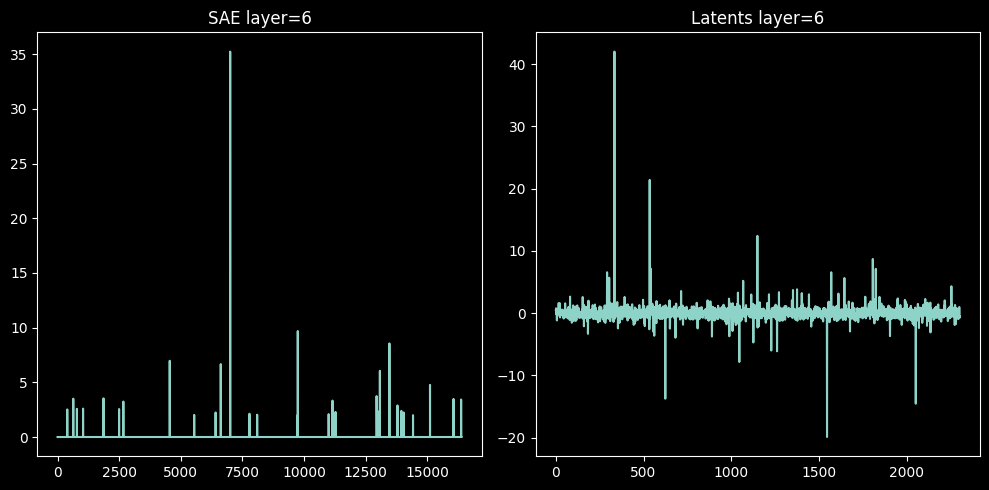

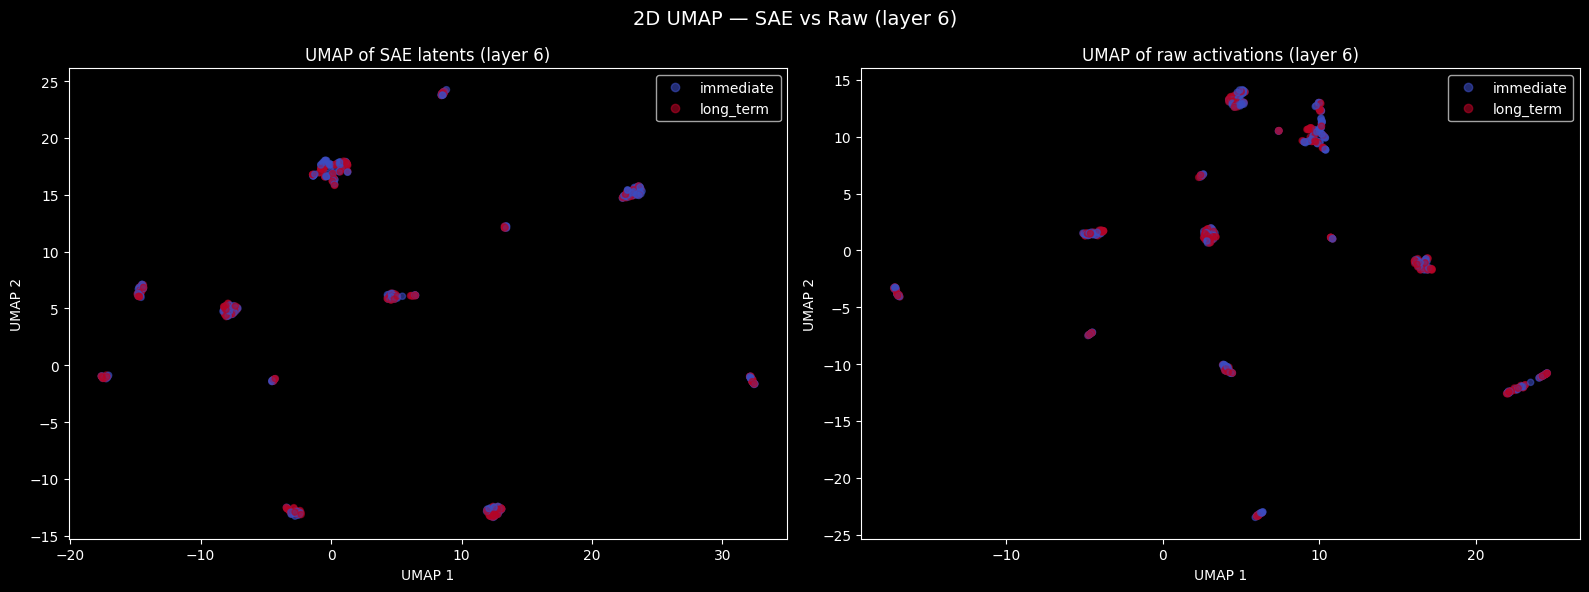

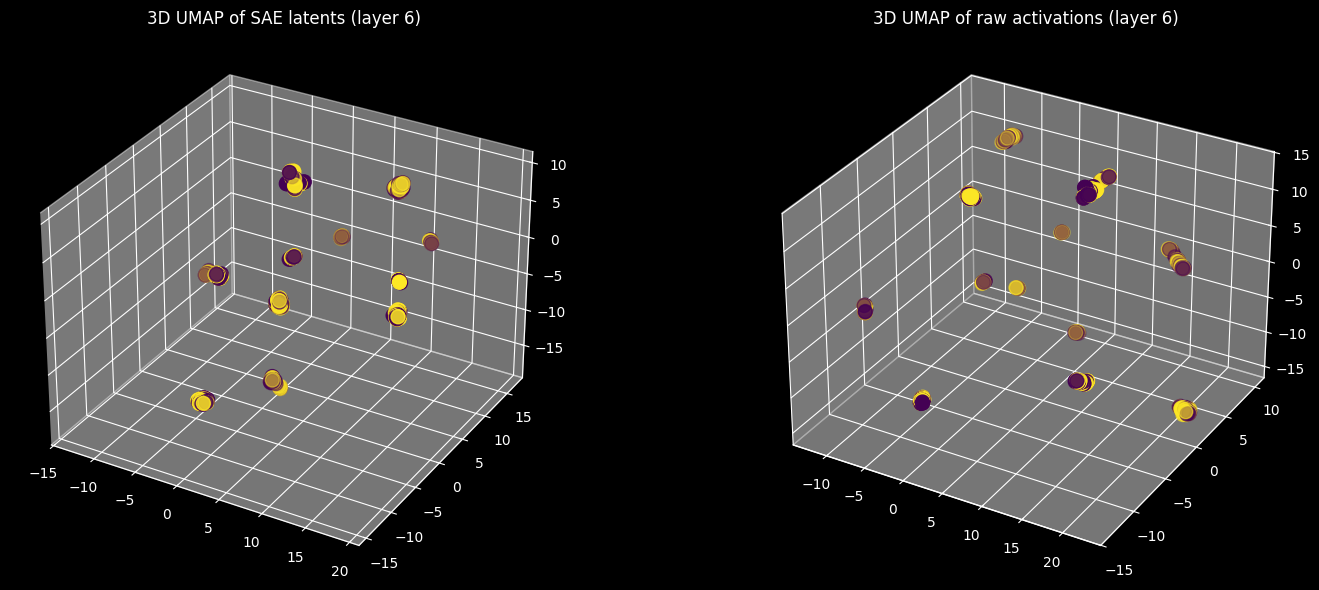


Layer 13


/tmp/ipykernel_7825/3289226410.py:6: DeprecationWarning: Getting length of SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  all_sae_latents = [] if sae else None
Batches: 100%|██████████| 38/38 [00:40<00:00,  1.07s/it]

Raw activations shape: (600, 2304)
SAE latents shape: (600, 16384)
Mean SAE sparsity: 0.0058



/tmp/ipykernel_7825/3289226410.py:28: DeprecationWarning: Getting length of SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  sae_latents = np.concatenate(all_sae_latents, axis=0) if sae else None


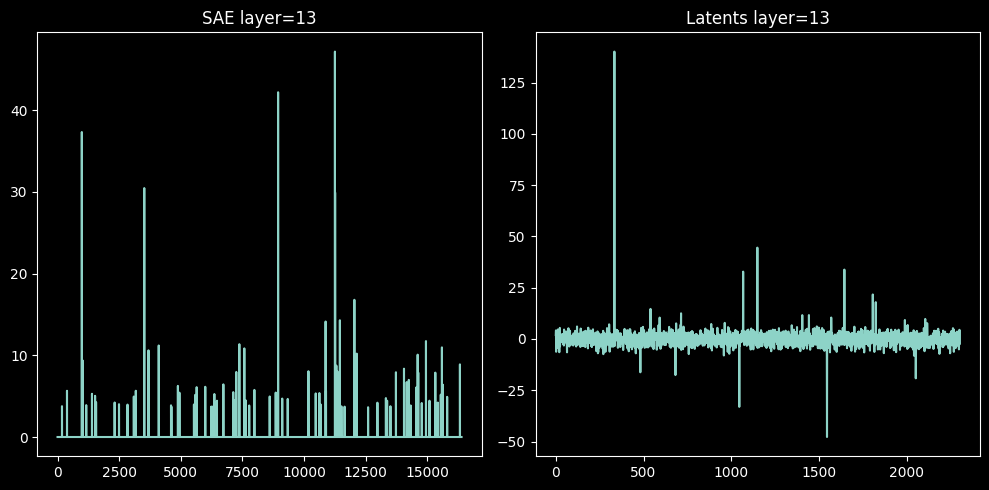

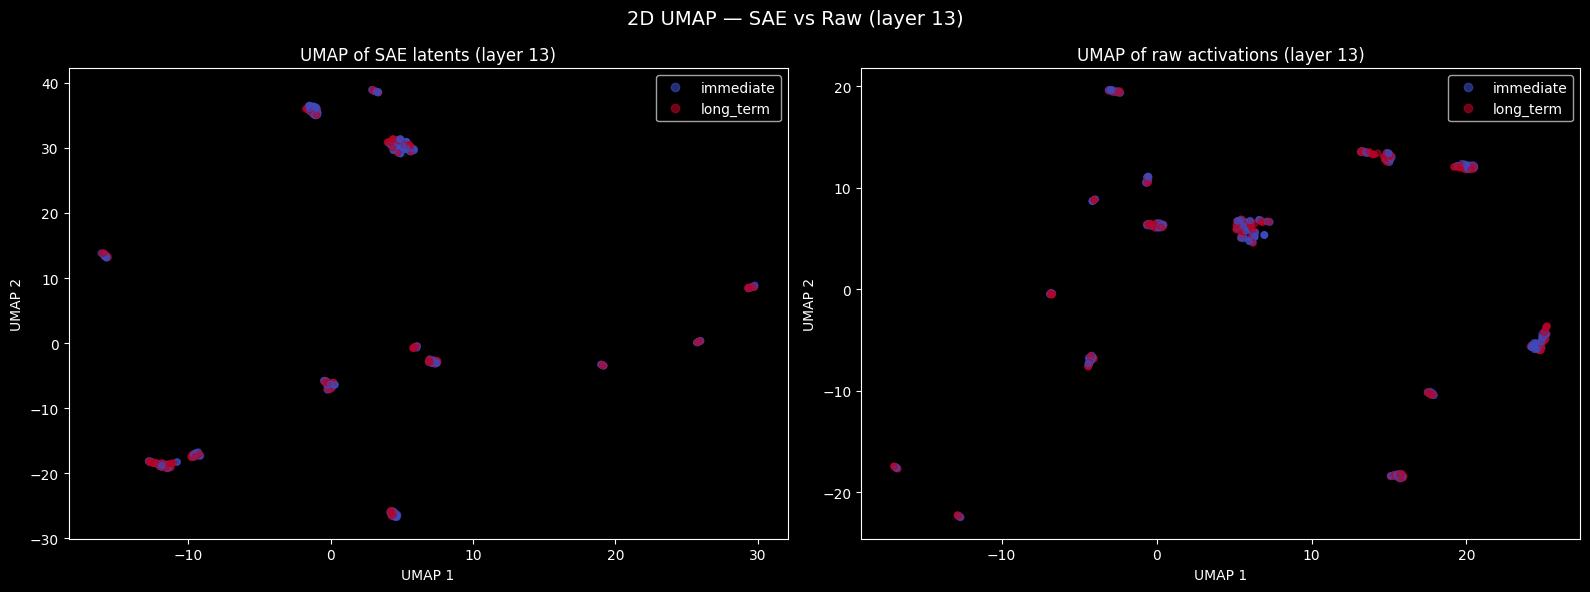

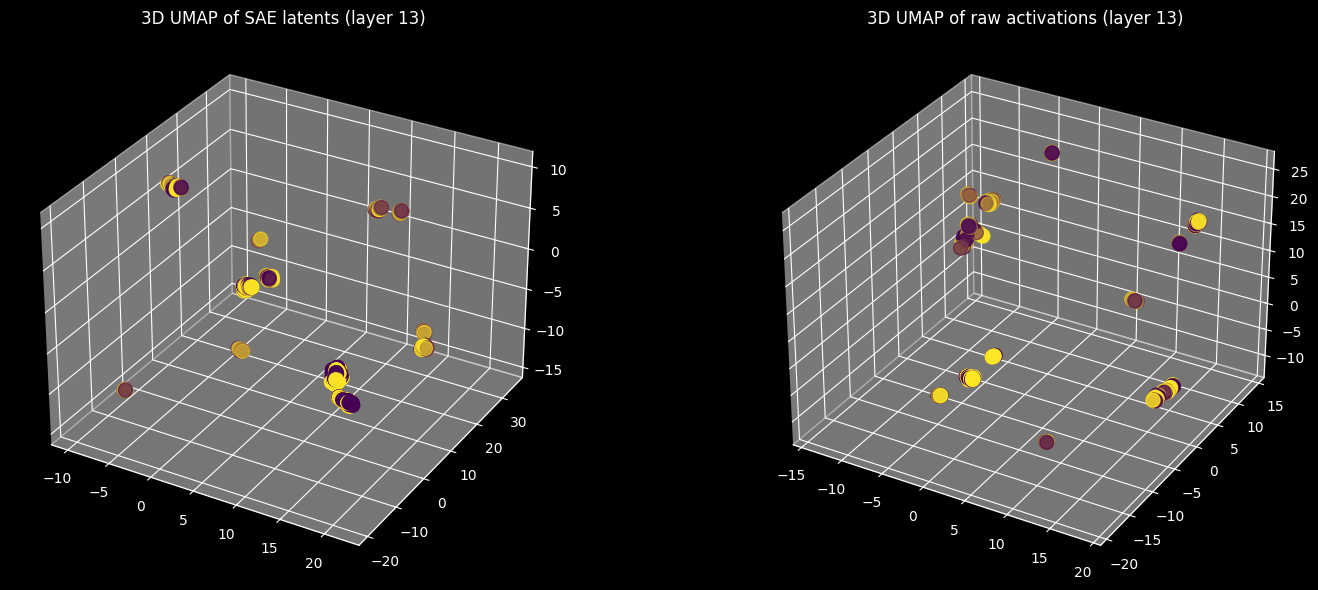


Layer 20


/tmp/ipykernel_7825/3289226410.py:6: DeprecationWarning: Getting length of SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  all_sae_latents = [] if sae else None
Batches: 100%|██████████| 38/38 [00:53<00:00,  1.41s/it]

Raw activations shape: (600, 2304)
SAE latents shape: (600, 16384)
Mean SAE sparsity: 0.0020



/tmp/ipykernel_7825/3289226410.py:28: DeprecationWarning: Getting length of SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  sae_latents = np.concatenate(all_sae_latents, axis=0) if sae else None


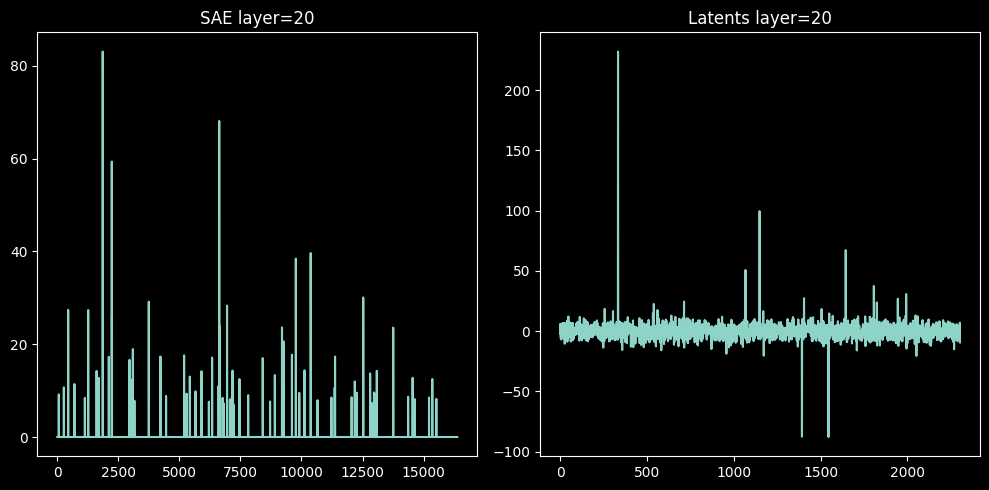

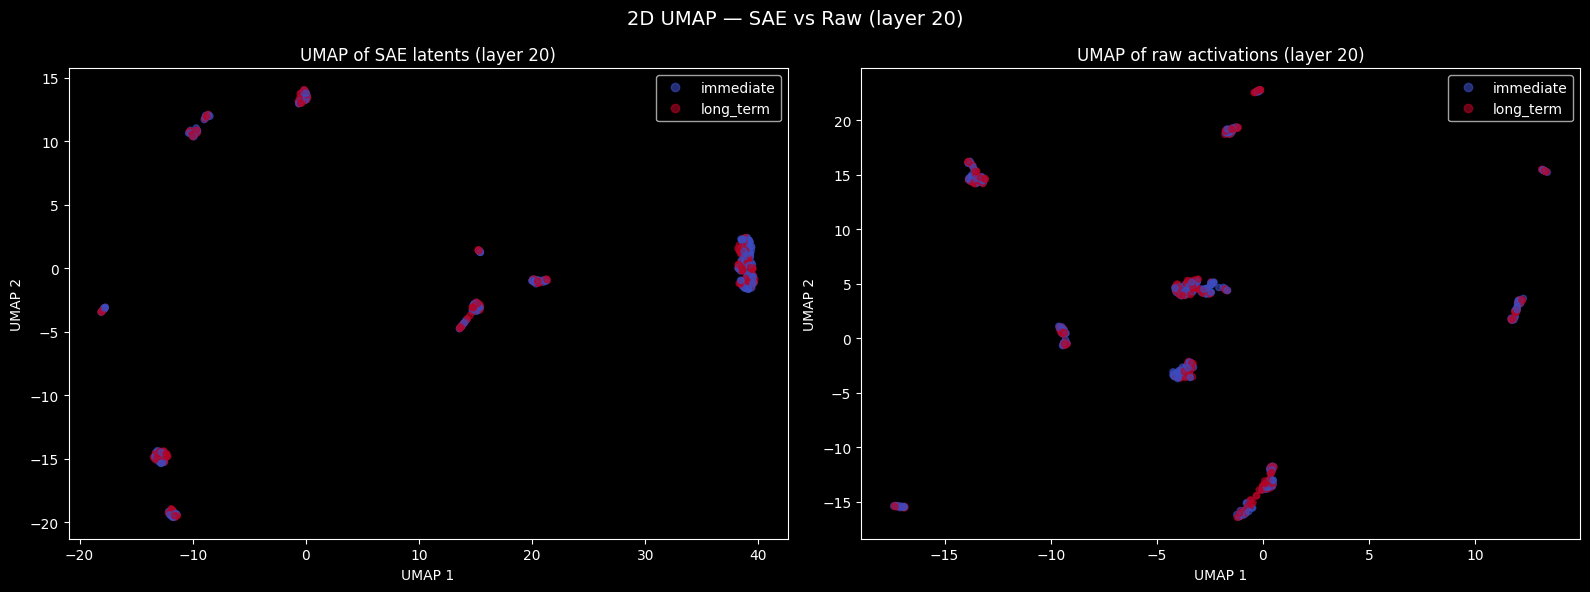

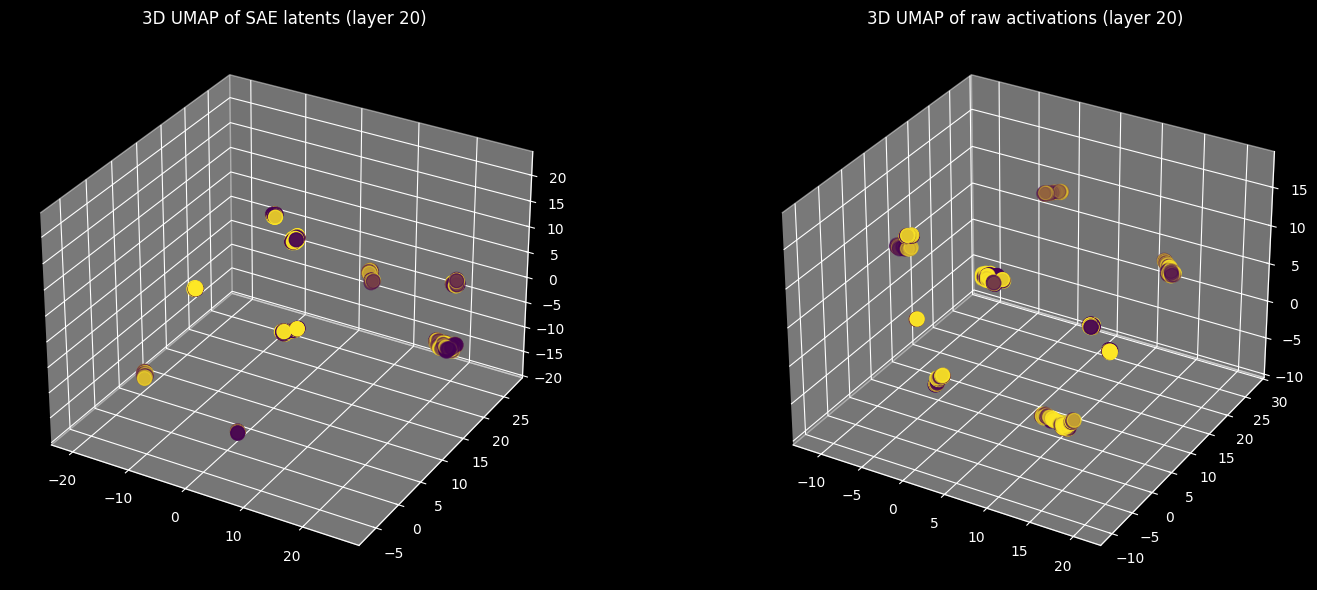


Layer 24


/tmp/ipykernel_7825/3289226410.py:6: DeprecationWarning: Getting length of SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  all_sae_latents = [] if sae else None
Batches: 100%|██████████| 38/38 [01:10<00:00,  1.86s/it]

Raw activations shape: (600, 2304)
SAE latents shape: (600, 16384)
Mean SAE sparsity: 0.0017



/tmp/ipykernel_7825/3289226410.py:28: DeprecationWarning: Getting length of SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  sae_latents = np.concatenate(all_sae_latents, axis=0) if sae else None


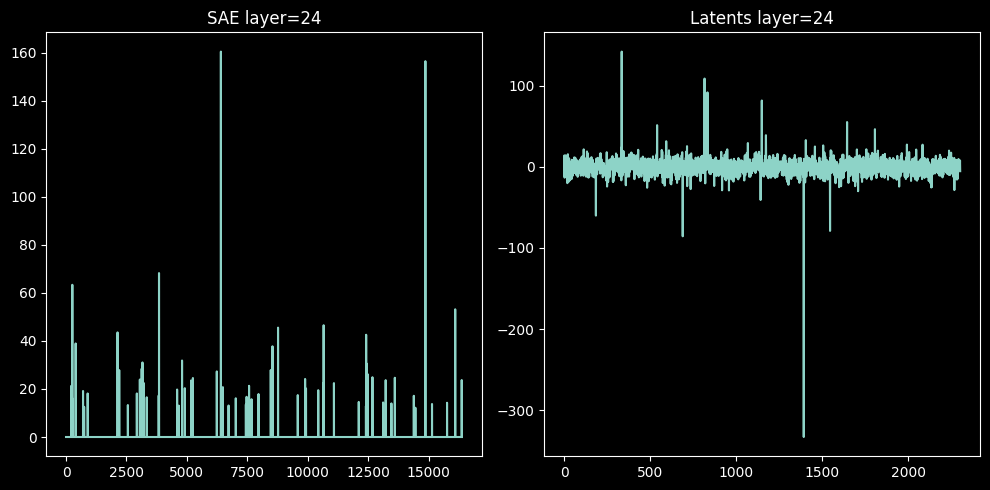

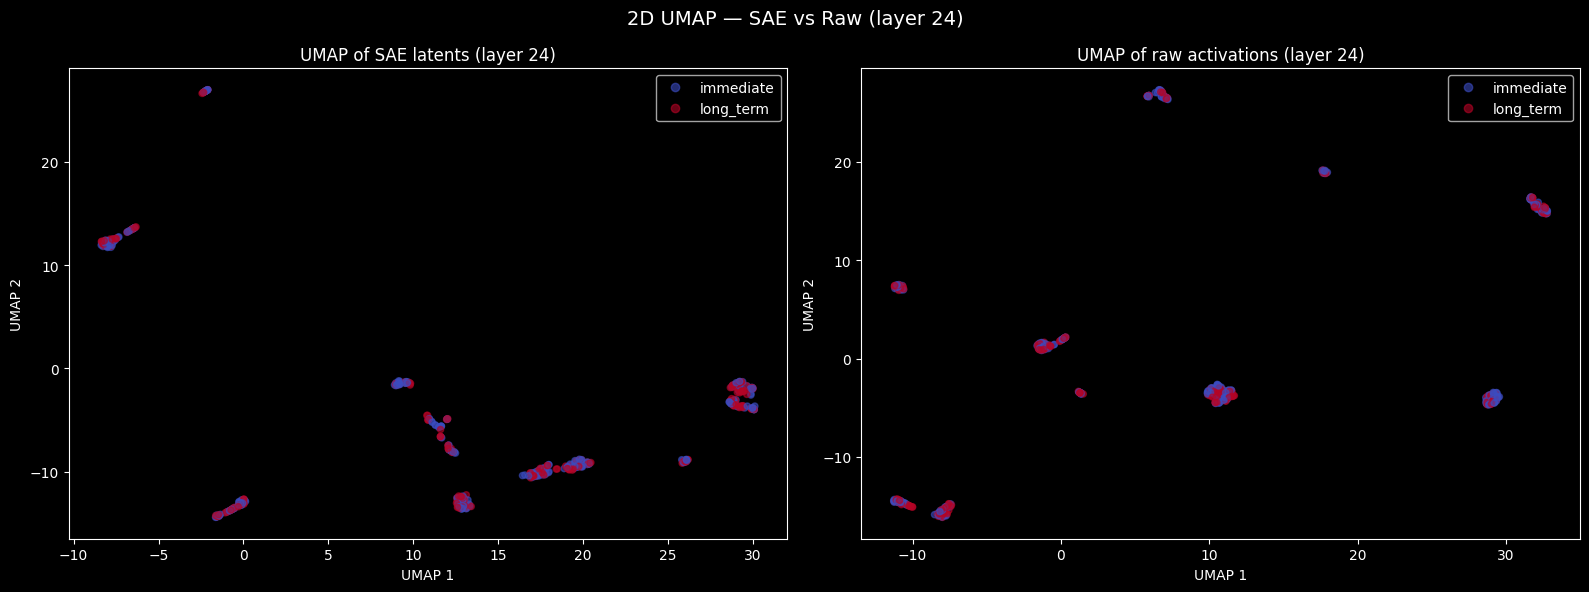

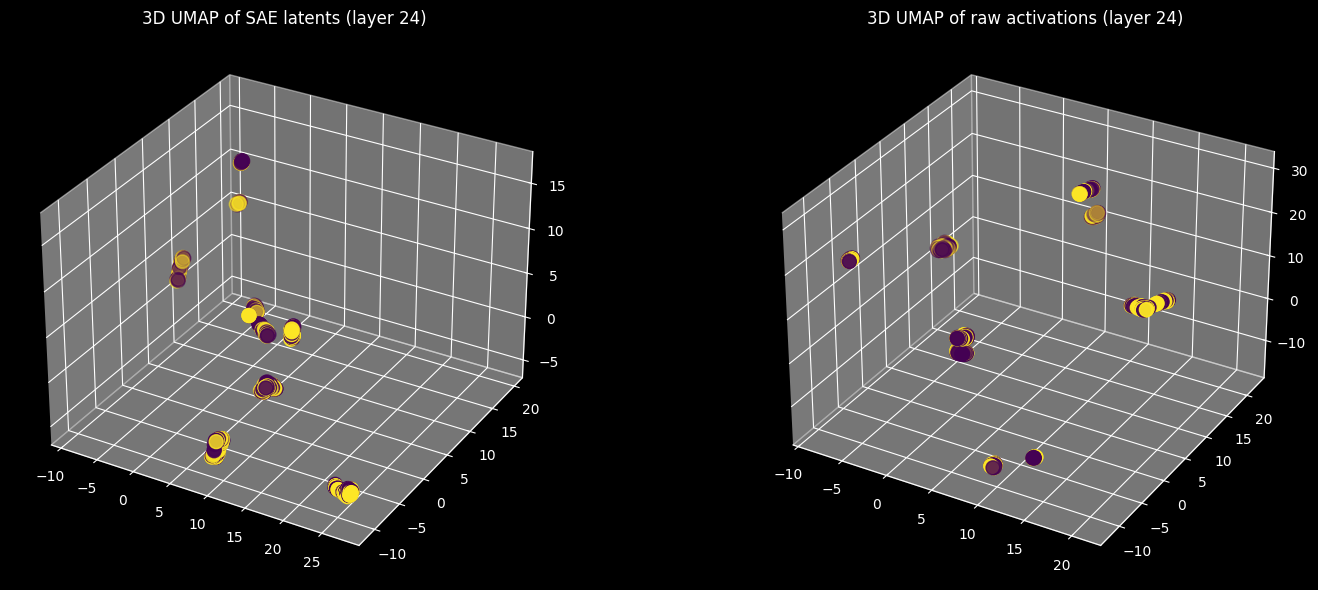

In [20]:
import umap
import warnings

labels_arr = np.array(labels)

for layer in config.layers:
    print(f"\n{'='*60}")
    print(f"Layer {layer}")
    print(f"{'='*60}")

    # Load SAE for this layer
    sae_id = f"layer_{layer}/width_{config.sae_width}/canonical"
    sae = SAE.from_pretrained(release=config.sae_release, sae_id=sae_id, device=config.device)

    # Extract activations
    train_acts, sae_train_latents = extract_activations(model, texts, layer, sae=sae)

    # Plot raw signals
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].set_title(f"SAE layer={layer}")
    ax[0].plot(sae_train_latents[0])
    ax[1].set_title(f"Latents layer={layer}")
    ax[1].plot(train_acts[0])
    plt.tight_layout()
    plt.show()

    # UMAP 2D — SAE latents
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        sae_embedding = umap.UMAP(n_components=2).fit_transform(sae_train_latents)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    scatter = axes[0].scatter(
        sae_embedding[:, 0], sae_embedding[:, 1],
        c=labels_arr, cmap="coolwarm", alpha=0.6, s=20,
    )
    axes[0].set_xlabel("UMAP 1")
    axes[0].set_ylabel("UMAP 2")
    axes[0].set_title(f"UMAP of SAE latents (layer {layer})")
    handles, _ = scatter.legend_elements()
    axes[0].legend(handles, ["immediate", "long_term"])

    # UMAP 2D — Raw activations
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        raw_embedding = umap.UMAP(n_components=2).fit_transform(train_acts)

    scatter = axes[1].scatter(
        raw_embedding[:, 0], raw_embedding[:, 1],
        c=labels_arr, cmap="coolwarm", alpha=0.6, s=20,
    )
    axes[1].set_xlabel("UMAP 1")
    axes[1].set_ylabel("UMAP 2")
    axes[1].set_title(f"UMAP of raw activations (layer {layer})")
    handles, _ = scatter.legend_elements()
    axes[1].legend(handles, ["immediate", "long_term"])

    plt.suptitle(f"2D UMAP — SAE vs Raw (layer {layer})", fontsize=14)
    plt.tight_layout()
    plt.show()

    # UMAP 3D — SAE latents and Raw activations
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        sae_embedding_3d = umap.UMAP(n_components=3).fit_transform(sae_train_latents)
        raw_embedding_3d = umap.UMAP(n_components=3).fit_transform(train_acts)

    fig = plt.figure(figsize=(16, 6))

    ax = fig.add_subplot(121, projection='3d')
    ax.scatter(sae_embedding_3d[:,0], sae_embedding_3d[:,1], sae_embedding_3d[:,2], c=labels_arr, s=100)
    ax.set_title(f"3D UMAP of SAE latents (layer {layer})")

    ax = fig.add_subplot(122, projection='3d')
    ax.scatter(raw_embedding_3d[:,0], raw_embedding_3d[:,1], raw_embedding_3d[:,2], c=labels_arr, s=100)
    ax.set_title(f"3D UMAP of raw activations (layer {layer})")

    plt.tight_layout()
    plt.show()

## Part 2: Numerical Time Scale (10-class)

We use the `temporal_numerical.json` dataset which has 156 templates with a blank (`___`) that gets filled with one of 10 time labels (from "now" to "100 years"). Expanding every template across all 10 labels gives us 1560 sentences. We then extract activations and run UMAP to see whether the 10 time classes form separable clusters.

In [21]:
# Load and expand temporal_numerical dataset
with open(DATA_DIR / "temporal_numerical" / "temporal_numerical.json") as f:
    num_data = json.load(f)

time_labels_map = num_data["metadata"]["time_labels"]  # {"0": "now", "1": "one day", ...}

num_texts = []
num_labels = []

for sample in num_data["samples"]:
    template = sample["template"]
    for label_idx in range(10):
        time_str = time_labels_map[str(label_idx)]
        num_texts.append(template.replace("___", time_str))
        num_labels.append(label_idx)

print(f"Templates: {len(num_data['samples'])}")
print(f"Time labels: {list(time_labels_map.values())}")
print(f"Total samples: {len(num_texts)} ({len(num_data['samples'])} templates × 10 labels)")
print(f"\nExample expansions of first template:")
for i in range(10):
    print(f"  [{i}] {num_texts[i]}")

Templates: 156
Time labels: ['now', 'one day', 'one week', 'two weeks', 'one month', 'half a year', 'one year', '5 years', '10 years', '100 years']
Total samples: 1560 (156 templates × 10 labels)

Example expansions of first template:
  [0] I want to take a vacation in now.
  [1] I want to take a vacation in one day.
  [2] I want to take a vacation in one week.
  [3] I want to take a vacation in two weeks.
  [4] I want to take a vacation in one month.
  [5] I want to take a vacation in half a year.
  [6] I want to take a vacation in one year.
  [7] I want to take a vacation in 5 years.
  [8] I want to take a vacation in 10 years.
  [9] I want to take a vacation in 100 years.



Layer 6


/tmp/ipykernel_7825/3289226410.py:6: DeprecationWarning: Getting length of SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  all_sae_latents = [] if sae else None
Batches: 100%|██████████| 98/98 [01:14<00:00,  1.31it/s]
/tmp/ipykernel_7825/3289226410.py:28: DeprecationWarning: Getting length of SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  sae_latents = np.concatenate(all_sae_latents, axis=0) if sae else None


Raw activations shape: (1560, 2304)
SAE latents shape: (1560, 16384)
Mean SAE sparsity: 0.0112


/tmp/ipykernel_7825/163644596.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


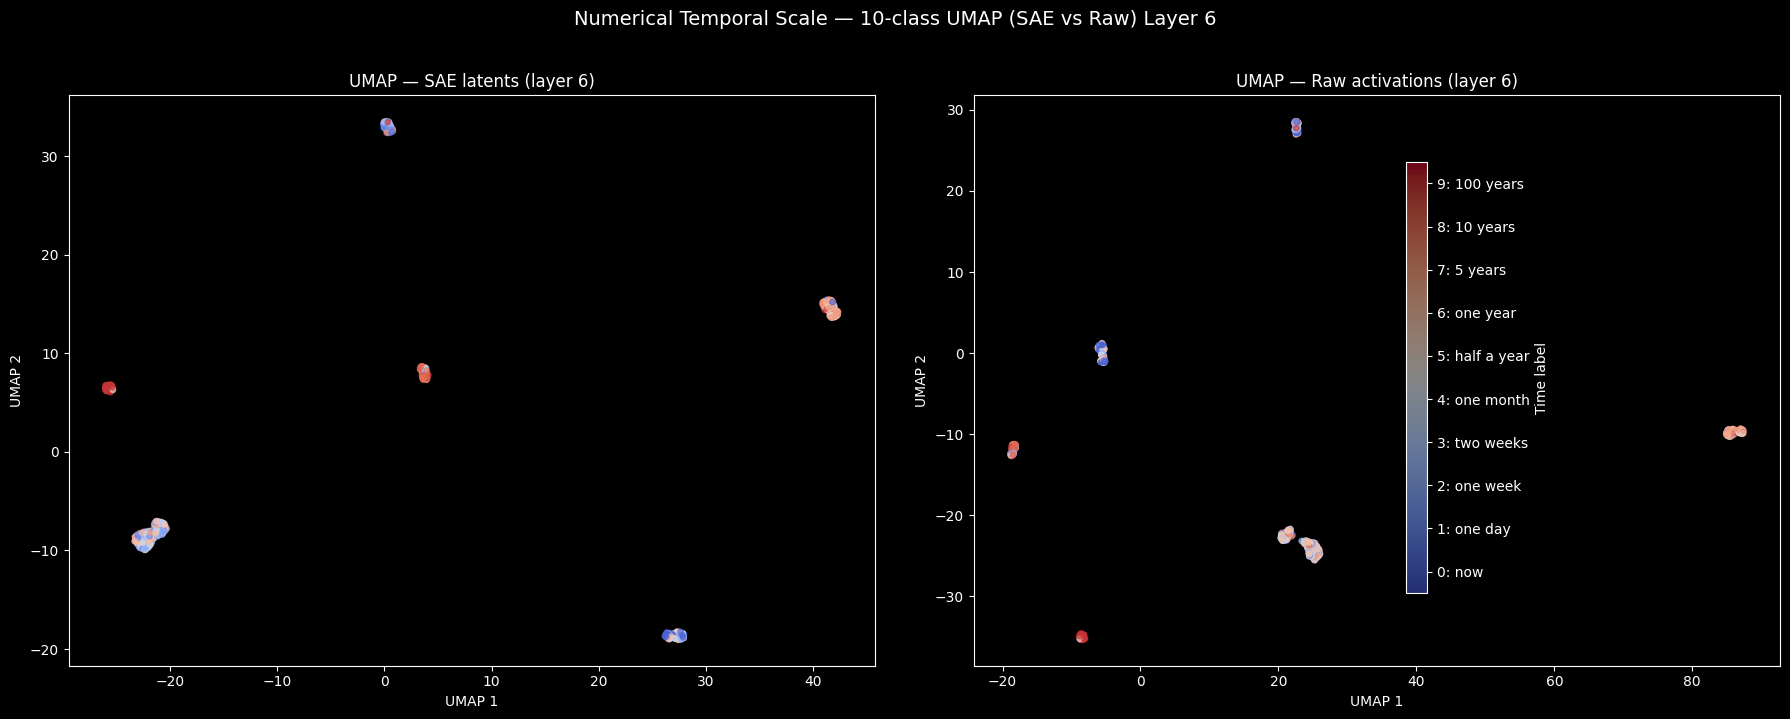


Layer 13


/tmp/ipykernel_7825/3289226410.py:6: DeprecationWarning: Getting length of SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  all_sae_latents = [] if sae else None
Batches: 100%|██████████| 98/98 [02:09<00:00,  1.33s/it]
/tmp/ipykernel_7825/3289226410.py:28: DeprecationWarning: Getting length of SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  sae_latents = np.concatenate(all_sae_latents, axis=0) if sae else None


Raw activations shape: (1560, 2304)
SAE latents shape: (1560, 16384)
Mean SAE sparsity: 0.0056


/tmp/ipykernel_7825/163644596.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


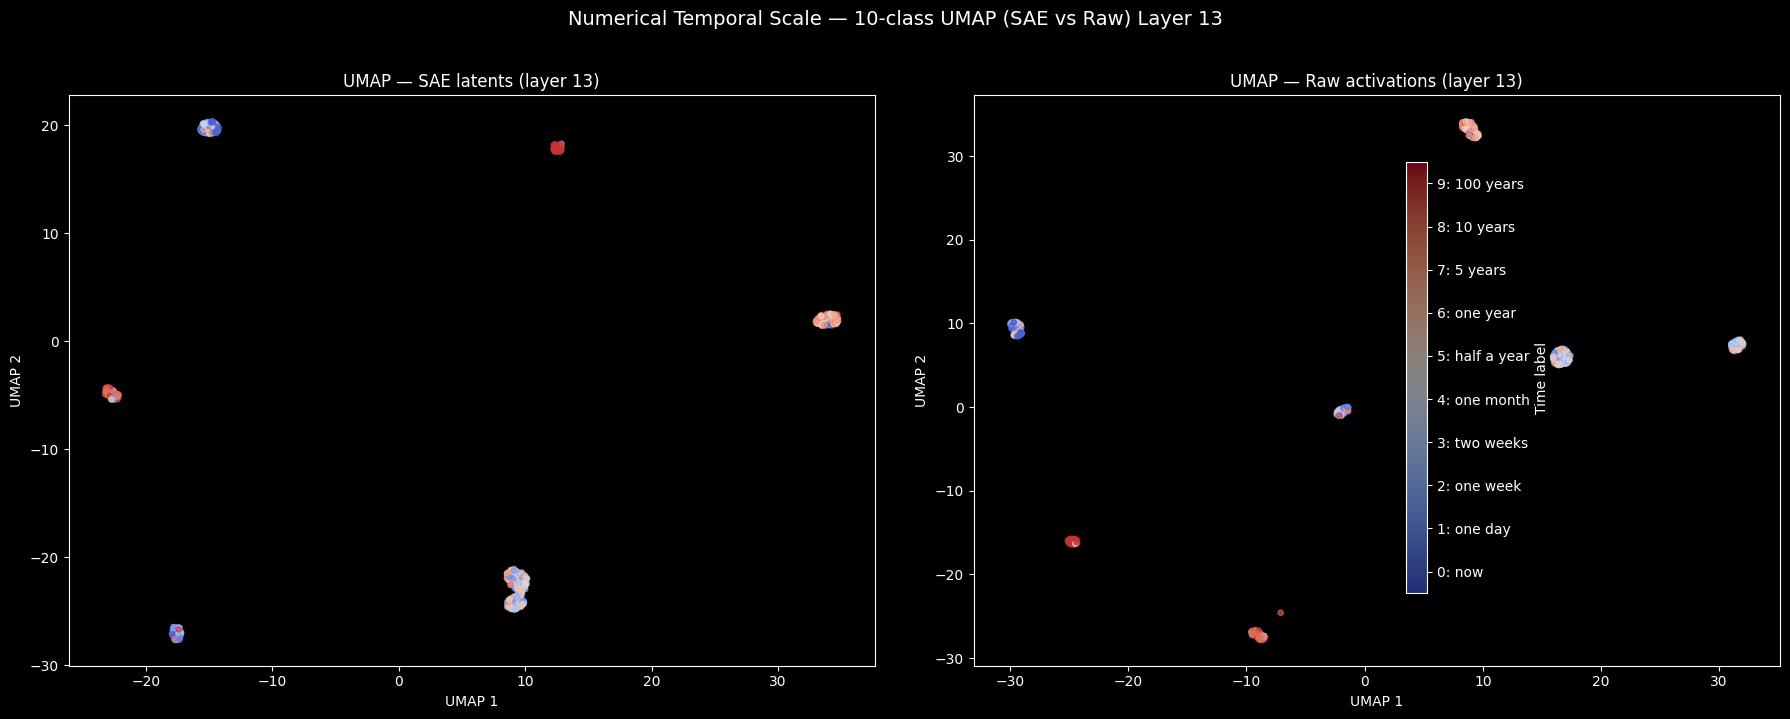


Layer 20


/tmp/ipykernel_7825/3289226410.py:6: DeprecationWarning: Getting length of SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  all_sae_latents = [] if sae else None
Batches: 100%|██████████| 98/98 [03:34<00:00,  2.19s/it]
/tmp/ipykernel_7825/3289226410.py:28: DeprecationWarning: Getting length of SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  sae_latents = np.concatenate(all_sae_latents, axis=0) if sae else None


Raw activations shape: (1560, 2304)
SAE latents shape: (1560, 16384)
Mean SAE sparsity: 0.0019


/tmp/ipykernel_7825/163644596.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


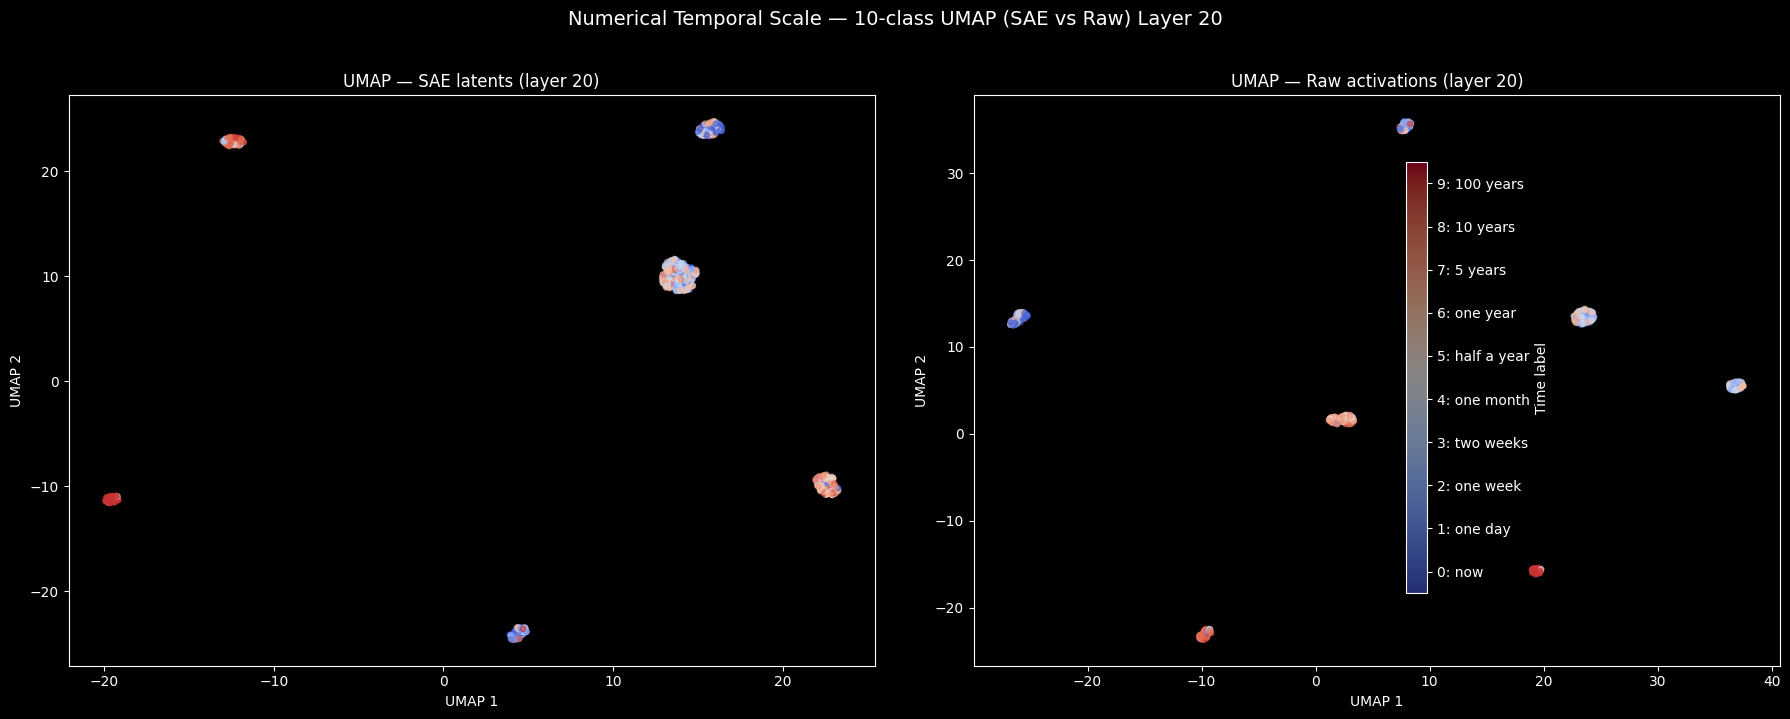


Layer 24


/tmp/ipykernel_7825/3289226410.py:6: DeprecationWarning: Getting length of SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  all_sae_latents = [] if sae else None
Batches: 100%|██████████| 98/98 [03:52<00:00,  2.37s/it]
/tmp/ipykernel_7825/3289226410.py:28: DeprecationWarning: Getting length of SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  sae_latents = np.concatenate(all_sae_latents, axis=0) if sae else None


Raw activations shape: (1560, 2304)
SAE latents shape: (1560, 16384)
Mean SAE sparsity: 0.0016


/tmp/ipykernel_7825/163644596.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


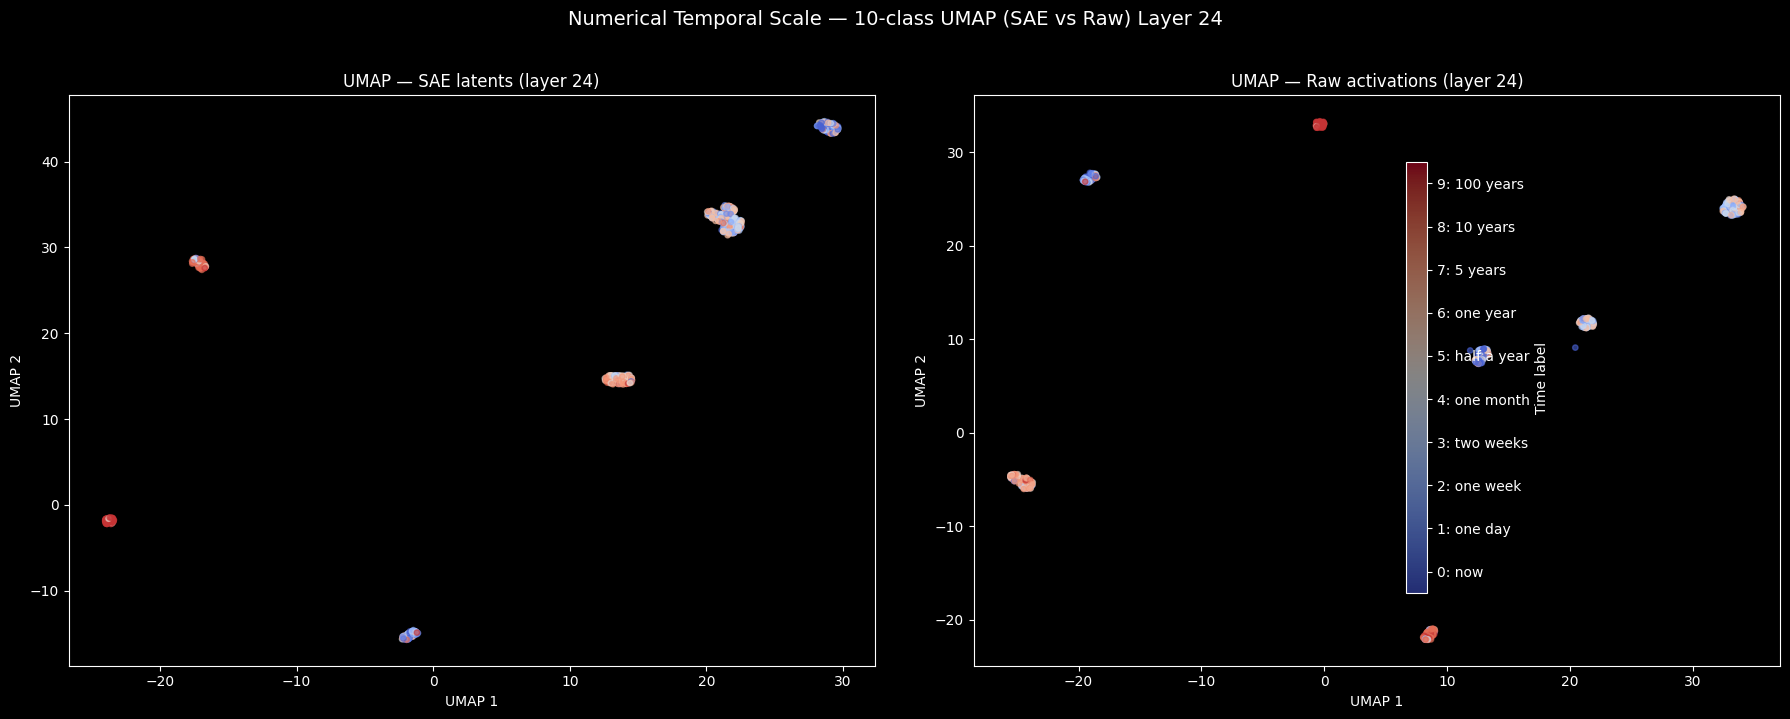

In [23]:
num_labels_arr = np.array(num_labels)
label_names = [time_labels_map[str(i)] for i in range(10)]

for layer in config.layers:
    print(f"\n{'='*60}")
    print(f"Layer {layer}")
    print(f"{'='*60}")

    # Load SAE for this layer
    sae_id = f"layer_{layer}/width_{config.sae_width}/canonical"
    sae = SAE.from_pretrained(release=config.sae_release, sae_id=sae_id, device=config.device)

    # Extract activations
    num_acts, num_sae_latents = extract_activations(model, num_texts, layer, sae=sae)

    # UMAP on SAE latents and raw activations side by side
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    for ax, data, title in [
        (axes[0], num_sae_latents, f"SAE latents (layer {layer})"),
        (axes[1], num_acts, f"Raw activations (layer {layer})"),
    ]:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=100)
            embedding = reducer.fit_transform(data)

        scatter = ax.scatter(
            embedding[:, 0], embedding[:, 1],
            c=num_labels_arr, cmap="coolwarm", alpha=0.6, s=15,
            vmin=-0.5, vmax=9.5,
        )
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")
        ax.set_title(f"UMAP — {title}")

    cbar = fig.colorbar(scatter, ax=axes, ticks=range(10), shrink=0.8)
    cbar.ax.set_yticklabels([f"{i}: {name}" for i, name in enumerate(label_names)])
    cbar.ax.set_ylabel("Time label")

    plt.suptitle(f"Numerical Temporal Scale — 10-class UMAP (SAE vs Raw) Layer {layer}", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()